In [71]:
import os
import yaml
import json

from pathlib import Path
from dotenv import load_dotenv
from pydantic import BaseModel
from typing import TypedDict,Literal,Optional
from datetime import datetime,timedelta

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq

In [72]:
load_dotenv()

True

In [73]:
taxomony_path=Path.cwd()/"taxomony.yaml"
print(taxomony_path)

c:\Users\khadk\OneDrive\Desktop\agents\notebooks\taxomony.yaml


In [74]:
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    print("Please add your groq api key in .env")

In [75]:
class DecisionOutput(BaseModel):
    trigger_id:Optional[str]=None
    task_result:bool
    evidence:str

In [76]:
class ClassifierAgent(TypedDict):
    #Input
    note:str
    taxonomy:str
    #Output
    decision:DecisionOutput
    
    record_id:str
    record_timestamp:str
    conn_pool:object
    workflow_id:Optional[str]
   


In [77]:
llm=ChatGroq(model="llama-3.3-70b-versatile")
model=llm.with_structured_output(DecisionOutput)

In [78]:
graph=StateGraph(ClassifierAgent)

In [79]:
def load_taxonomy() -> list[dict]:
    with open(taxomony_path) as f:
        return yaml.safe_load(f)["triggers"]
 
 
def build_classification_prompt(taxonomy: list[dict], note: str) -> str:
    trigger_block = "\n\n".join(
        f"id: {t['id']}\n"
        f"description: {t['description'].strip()}\n"
        f"positive examples: {t.get('examples_positive', [])}\n"
        f"negative examples: {t.get('examples_negative', [])}"
        for t in taxonomy
    )

    return f"""You are checking one NDIS support note against a fixed list of
reportable triggers. Only set task_result=true if the note clearly satisfies
a trigger's description, judged against its examples. If ambiguous, set
task_result=false rather than guessing. If task_result is false, leave
trigger_id as null.
 
Triggers:
{trigger_block}
 
Note to classify:
{note}
"""

In [80]:
def make_decision(state:ClassifierAgent):
    note=state.get("note")
    taxonomy=load_taxonomy()
    prompt=build_classification_prompt(taxonomy,note)
    result=model.invoke(prompt)

    return {"decision":result}

def create_task(state: ClassifierAgent) -> dict:
    taxonomy = load_taxonomy()
    decision = state["decision"]  
    trigger_def = next(t for t in taxonomy if t["id"] == decision.trigger_id)
 
    note_time = datetime.fromisoformat(state["record_timestamp"])
    deadline = note_time + timedelta(hours=trigger_def["deadline_hours"])
 
    conn_pool = state["conn_pool"]
    with conn_pool.connection() as conn:
        workflow_id = conn.execute(
            """
            INSERT INTO records (record_type, status, body, source, author)
            VALUES ('incident', 'draft', %(body)s, %(source)s, 'a2_agent')
            RETURNING id
            """,
            {
                "body": json.dumps({
                    "trigger_id": decision.trigger_id,
                    "reasoning": decision.evidence,
                    "workflow": trigger_def["workflow"],
                    "deadline": deadline.isoformat(),
                }),
                "source": f"a2:{state['record_id']}",
            },
        ).fetchone()[0]
 
        conn.execute(
            """
            INSERT INTO links (from_record_id, to_record_id, link_type)
            VALUES (%(from_id)s, %(to_id)s, 'triggered_by')
            """,
            {"from_id": str(workflow_id), "to_id": state["record_id"]},
        )
        conn.execute(
            """
            INSERT INTO events (actor, action, record_id, params)
            VALUES ('a2_agent', 'a2.trigger_matched', %(record_id)s, %(params)s)
            """,
            {
                "record_id": str(workflow_id),
                "params": json.dumps({"trigger_id": decision.trigger_id}),  
            },
        )
        conn.commit()
 
    return {"workflow_id": str(workflow_id)}

def no_match(state:ClassifierAgent)->dict:
    return {}

def check_decision(state:ClassifierAgent)->Literal["create_task","no_match"]:
    return "create_task" if state["decision"].task_result else "no_match"

In [81]:
graph.add_node('make_decision',make_decision)
graph.add_node('create_task',create_task)

graph.add_edge(START,'make_decision')
graph.add_conditional_edges('make_decision',check_decision,{"create_task":"create_task","no_match":END})
graph.add_edge('create_task',END)


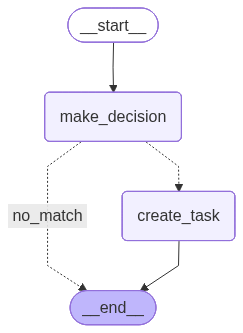

In [82]:
workflow=graph.compile()
workflow

In [83]:
note="""
The participant reported feeling okay, but still finds it hard to get out of the house. They managed to go to the shops twice, which is great progress toward their goal of increasing community participation. They felt a bit anxious while catching the bus, but were able to do it. They also mentioned needing help with their grocery list next time.

The participant demonstrated progress toward their goal of increasing community participation by going to the shops twice and catching the bus both times. They were able to manage their anxiety and sit near the front of the bus when it was crowded.

Work on creating a grocery list for the participant in the next session to further support their community participation.

The participant expressed that they need help with their grocery list next time and felt anxious while catching the bus, but were proud of themselves for going to the shops twice.
"""

In [84]:
res=workflow.invoke({
    "note":note,
    "taxomony":"",
    "decision":"",
    "record_id": "test-record-id",
    "conn_pool":None
})

In [85]:
print(res.get('decision'))

trigger_id=None task_result=False evidence='The participant reported feeling okay, but still finds it hard to get out of the house. They managed to go to the shops twice, which is great progress toward their goal of increasing community participation. They felt a bit anxious while catching the bus, but were able to do it. They also mentioned needing help with their grocery list next time.'
